In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm 
import albumentations as A
from albumentations.pytorch import ToTensorV2

import faiss 
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import scipy.io
from sklearn.model_selection import train_test_split

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EMBEDDING_DIM = 256
BATCH_SIZE = 64
NUM_WORKERS = 0

In [3]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

def get_train_transforms():
    return A.Compose([
        A.Resize(224, 224),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
        A.HueSaturationValue(p=0.3),
        A.GaussNoise(p=0.2),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ])

class Cars196Dataset(Dataset):
    def __init__(self, data, data_dir, transforms=None):
        super().__init__()
        self.data = data
        self.data_dir = data_dir
        self.transforms = transforms

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        img_path = self.data_dir + self.data.iloc[idx]['img_path']
        label = self.data.iloc[idx]['class'] 
        
        image = Image.open(img_path).convert('RGB')
        image = np.array(image)

        if self.transforms:
            image = self.transforms(image=image)['image']
        
        return image, torch.tensor(label, dtype=torch.long)


class CarsDataModule(pl.LightningDataModule):
    def __init__(self, train_path, devkit_path, batch_size=32, num_workers=4, val_split=0.2, random_seed=42):
        super().__init__()
        self.train_path = train_path
        self.devkit_path = devkit_path
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.val_split = val_split
        self.random_seed = random_seed
        
        self.train_transforms = get_train_transforms()
        self.val_transforms = get_val_transforms()

    def setup(self, stage=None):
        annos_path = f'{self.devkit_path}/cars_train_annos.mat'
        mat = scipy.io.loadmat(annos_path)
        
        fname_to_class = {
            fname[0]: cl[0][0] - 1 
            for fname, cl in zip(
                mat['annotations'][0]['fname'],
                mat['annotations'][0]['class']
            )
        }
        
        data = pd.DataFrame(fname_to_class.items(), columns=['img_path', 'class'])
        
        self.train_df, self.val_df = train_test_split(
            data, 
            test_size=self.val_split, 
            random_state=self.random_seed, 
            stratify=data['class']
        )
        # ----------------------------------------------
        
        data_dir = self.train_path + '/' 
        
        self.train_dataset = Cars196Dataset(
            self.train_df, data_dir, self.train_transforms
        )
        self.val_dataset = Cars196Dataset(
            self.val_df, data_dir, self.val_transforms
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True
        )


In [7]:
class EmbeddingNet(pl.LightningModule):
    def __init__(self, embedding_dim=EMBEDDING_DIM, lr=1e-4, margin=0.2):
        super().__init__()
        self.save_hyperparameters()
        
        self.backbone = timm.create_model('efficientnet_b0', pretrained=True) 
        
        in_features = self.backbone.get_classifier().in_features
        self.backbone.classifier = nn.Linear(in_features, embedding_dim)
        
        self.loss_fn = nn.TripletMarginLoss(margin=margin)
        self.lr = lr
        
        self.validation_step_outputs = {'embeddings': [], 'labels': []}

    def forward(self, x):
        embeddings = self.backbone(x)
        embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings

    def _batch_hard_triplet_loss(self, labels, embeddings):
        pairwise_dist = torch.cdist(embeddings, embeddings, p=2)

        mask_positive = (labels.unsqueeze(1) == labels.unsqueeze(0)) & (torch.eye(len(labels), device=self.device) == 0)
        mask_negative = (labels.unsqueeze(1) != labels.unsqueeze(0))

        anchor_positive_dist = pairwise_dist.clone()
        anchor_positive_dist[~mask_positive] = -float('inf')
        hardest_positive_dist, _ = torch.max(anchor_positive_dist, dim=1)

        anchor_negative_dist = pairwise_dist.clone()
        anchor_negative_dist[~mask_negative] = float('inf')
        hardest_negative_dist, _ = torch.min(anchor_negative_dist, dim=1)

        loss = F.relu(self.loss_fn.margin + hardest_positive_dist - hardest_negative_dist)
        
        return loss.mean()
    
    def training_step(self, batch, batch_idx): 
        images, labels = batch
        embeddings = self(images)
        
        loss = self._batch_hard_triplet_loss(labels, embeddings)
        
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        embeddings = self(images)
        self.validation_step_outputs['embeddings'].append(embeddings.detach())
        self.validation_step_outputs['labels'].append(labels.detach())

    def on_validation_epoch_end(self):
        if self.trainer.sanity_checking:
            print("Skipping Faiss for sanity check to speed up.")
            self.validation_step_outputs['embeddings'].clear()
            self.validation_step_outputs['labels'].clear()
            return
        
        all_embeddings = torch.cat(self.validation_step_outputs['embeddings']).cpu()
        all_labels = torch.cat(self.validation_step_outputs['labels']).cpu()
        
        self.validation_step_outputs['embeddings'].clear()
        self.validation_step_outputs['labels'].clear()
        
        SAMPLE_SIZE = 1024 
        
        if len(all_embeddings) > SAMPLE_SIZE:
            indices = torch.randperm(len(all_embeddings))[:SAMPLE_SIZE]
            sampled_embeddings = all_embeddings[indices]
            sampled_labels = all_labels[indices]
        else:
            sampled_embeddings = all_embeddings
            sampled_labels = all_labels
            
        print(f"Calculating metrics on sampled size: {len(sampled_embeddings)}")
        
        self.metric_calculator = MetricCalculator(sampled_embeddings, sampled_labels)
        ks = [1, 5, 10]
        for k in ks:
            precision_k = self.metric_calculator.precision_at_k(k)
            recall_k = self.metric_calculator.recall_at_k(k)
            map_k = self.metric_calculator.map_at_k(k)
            
            self.log(f'val_P@{k}', precision_k, prog_bar=True)
            self.log(f'val_R@{k}', recall_k)
            self.log(f'val_mAP@{k}', map_k, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_mAP@5", 
                "interval": "epoch",
                "frequency": 1,
            },
        }

In [8]:
class MetricCalculator:
    def __init__(self, embeddings, labels, k_max=20):
        print("Building Faiss index...")
        self.embeddings = embeddings.numpy()
        self.labels = labels.numpy()
        self.n_samples = len(labels)
        
        self.labels_to_indices = {}
        for idx, label in enumerate(self.labels):
            if label not in self.labels_to_indices:
                self.labels_to_indices[label] = []
            self.labels_to_indices[label].append(idx)
        
        self.total_relevant = {label: len(indices) for label, indices in self.labels_to_indices.items()}
        
        d = self.embeddings.shape[1]
                
        print("Building Faiss CPU index")
        self.index = faiss.IndexFlatL2(d)
        
        self.index.add(self.embeddings)
        print("Faiss index built.")

        self.D_all, self.I_all = self.index.search(self.embeddings, k_max + 1)

    def _get_neighbors_at_k(self, k):
        neighbor_indices = self.I_all[:, 1:k+1]
        neighbor_labels = self.labels[neighbor_indices]
        return neighbor_labels

    def precision_at_k(self, k):
        neighbor_labels = self._get_neighbors_at_k(k)
        query_labels = self.labels.reshape(-1, 1) 
        
        correct_matches = (neighbor_labels == query_labels)
        relevant_counts = np.sum(correct_matches, axis=1)
        
        precision_per_query = relevant_counts / k
        return np.mean(precision_per_query)

    def recall_at_k(self, k):
        neighbor_labels = self._get_neighbors_at_k(k)
        query_labels = self.labels.reshape(-1, 1) 

        correct_matches = (neighbor_labels == query_labels)
        relevant_counts = np.sum(correct_matches, axis=1) 
        
        total_relevant_per_query = np.array([self.total_relevant[label] - 1 for label in self.labels])
        total_relevant_per_query[total_relevant_per_query == 0] = 1 
        
        recall_per_query = relevant_counts / total_relevant_per_query
        return np.mean(recall_per_query)

    def map_at_k(self, k):
        neighbor_labels = self._get_neighbors_at_k(k)
        query_labels = self.labels.reshape(-1, 1) 
        
        correct_matches = (neighbor_labels == query_labels) # (N, k)
        
        ap_sum = 0.0
        for i in range(self.n_samples):
            query_label = self.labels[i]
            total_relevant_count = self.total_relevant[query_label] - 1
            if total_relevant_count == 0:
                continue

            matches_k = correct_matches[i]
            cumulative_matches = np.cumsum(matches_k)
            precision_at_i = cumulative_matches / (np.arange(k) + 1)
            
            average_precision = np.sum(precision_at_i * matches_k) / total_relevant_count
            ap_sum += average_precision
            
        return ap_sum / self.n_samples


In [9]:
TRAIN_PATH = './cars_train/cars_train'
DEVKIT_PATH = './devkit'

data_module = CarsDataModule(
    train_path=TRAIN_PATH,
    devkit_path=DEVKIT_PATH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    val_split=0.2
)

model = EmbeddingNet(embedding_dim=EMBEDDING_DIM, lr=1e-4, margin=0.2)

checkpoint_callback = ModelCheckpoint(
    monitor='val_mAP@5',
    dirpath='checkpoints/',
    filename='best_model_effnet_triplet',
    save_top_k=1,
    mode='max'
)

trainer = pl.Trainer(
    max_epochs=20,
    accelerator='gpu',
    devices=1,
    callbacks=[checkpoint_callback],
    precision='16-mixed'
)

trainer.fit(model, data_module)

print(f"Лучшая модель сохранена в: {checkpoint_callback.best_model_path}")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
D:\Iterpretators\Python3.11\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:751: Checkpoint directory D:\VK ML\Neural Networks\hw7\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
D:\Iterpretators\Python3.11\Lib\site-packages\pytorch_lightning\utilities\model_summary\model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | backbone | EfficientNet      | 4.3 M  | train
1 | loss_fn  | TripletMarginLoss | 0      | train
-------------------------------------------------------
4.3 M     Trainable params
0         Non-trainable params
4.3 M     Total params
17.342    Total estimated m

Sanity Checking: |                                                                               | 0/? [00:00<…

D:\Iterpretators\Python3.11\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Skipping Faiss for sanity check to speed up.


D:\Iterpretators\Python3.11\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

Calculating metrics on sampled size: 1024
Building Faiss index...
Building Faiss CPU index
Faiss index built.


Validation: |                                                                                    | 0/? [00:00<…

Calculating metrics on sampled size: 1024
Building Faiss index...
Building Faiss CPU index
Faiss index built.


`Trainer.fit` stopped: `max_epochs=20` reached.


Лучшая модель сохранена в: D:\VK ML\Neural Networks\hw7\checkpoints\best_model_effnet_triplet-v1.ckpt


Loading best model from: D:\VK ML\Neural Networks\hw7\checkpoints\best_model_effnet_triplet-v1.ckpt
Searching for 3 error pairs in the validation batch...


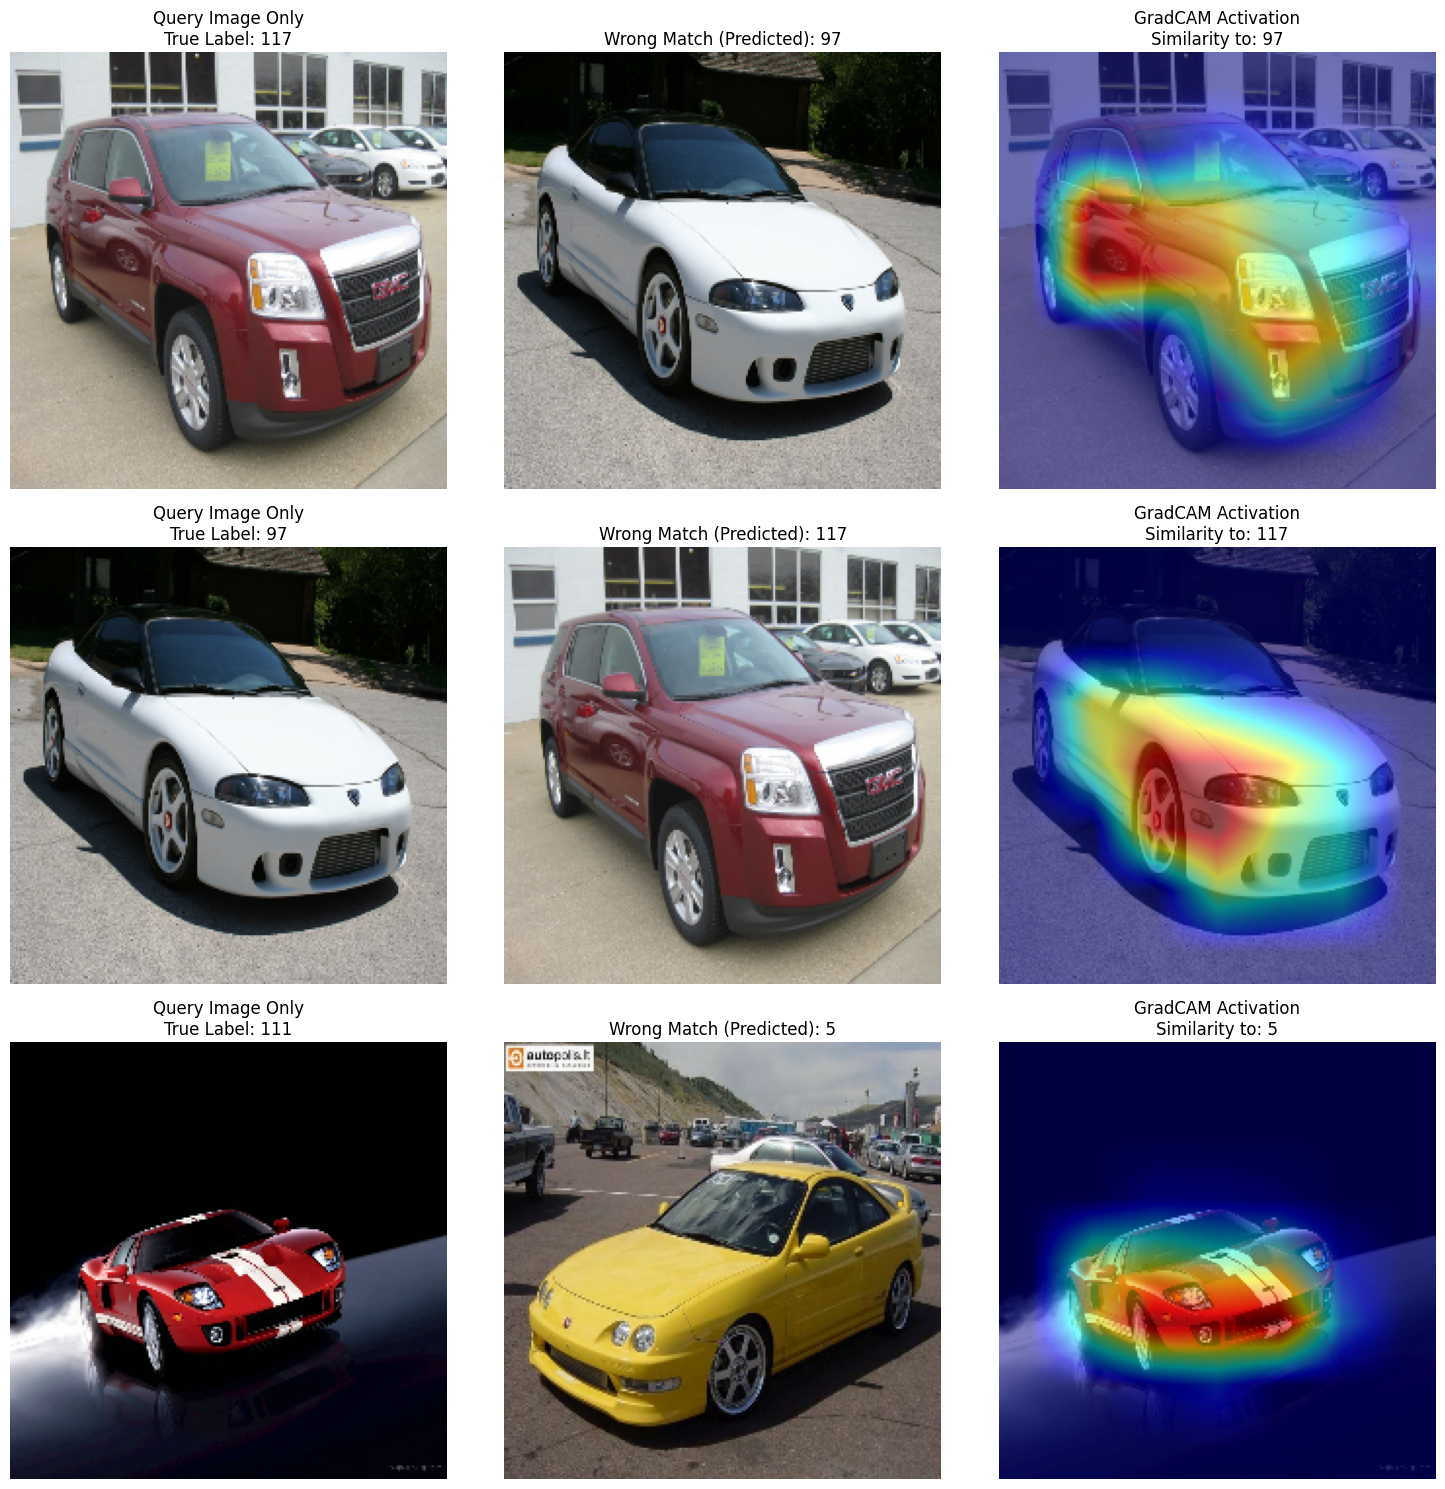

In [10]:
class EmbeddingSimilarityTarget:
    def __init__(self, target_embedding):
        self.target_embedding = F.normalize(target_embedding.to(DEVICE), p=2, dim=1) 

    def __call__(self, model_output):
        model_output_norm = F.normalize(model_output, p=2, dim=-1)
        similarity = torch.sum(model_output_norm * self.target_embedding, dim=1) 
        return similarity

BEST_MODEL_PATH = checkpoint_callback.best_model_path 
print(f"Loading best model from: {BEST_MODEL_PATH}")

model = EmbeddingNet.load_from_checkpoint(BEST_MODEL_PATH).to(DEVICE)
model.eval()

data_module.setup()
val_loader = data_module.val_dataloader() 
images, labels = next(iter(val_loader))

N_EXAMPLES_TO_SHOW = 3
error_examples = []
used_wrong_indices = []

print(f"Searching for {N_EXAMPLES_TO_SHOW} error pairs in the validation batch...")

for i in range(len(labels)):
    query_img_tensor = images[i]
    query_label = labels[i].item()

    wrong_img_tensor = None
    wrong_label = -1
    wrong_idx = -1
    
    for j in range(len(labels)):
        if i != j and labels[j].item() != query_label and j not in used_wrong_indices:
            wrong_img_tensor = images[j]
            wrong_label = labels[j].item()
            wrong_idx = j
            break
            
    if wrong_img_tensor is not None:
        error_examples.append({
            'query_tensor': query_img_tensor,
            'query_label': query_label,
            'wrong_tensor': wrong_img_tensor,
            'wrong_label': wrong_label
        })
        used_wrong_indices.append(wrong_idx)
        if len(error_examples) >= N_EXAMPLES_TO_SHOW:
            break

def denormalize(img):
    img_np = img.cpu().numpy().transpose((1, 2, 0))
    img_np = STD * img_np + MEAN
    img_np = np.clip(img_np, 0, 1)
    return img_np

def show_multiple_error_cams(model, errors, target_layer_name='conv_head'):
    
    target_layers = [model.backbone._modules.get(target_layer_name)]
    if target_layers[0] is None:
        target_layers = [model.backbone.features[-1]]
        print(f"Warning: '{target_layer_name}' not found. Using 'backbone.features[-1]' instead.")
        
    cam = GradCAM(model=model, target_layers=target_layers)
    
    N = len(errors)
    fig, axes = plt.subplots(N, 3, figsize=(15, 5 * N))
    
    if N == 1:
        axes = axes.reshape(1, -1) 
        
    for i, error in enumerate(errors):
        query_img_tensor = error['query_tensor']
        wrong_img_tensor = error['wrong_tensor']

        input_tensor = query_img_tensor.unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            wrong_embed = model(wrong_img_tensor.unsqueeze(0).to(DEVICE))


        targets = [EmbeddingSimilarityTarget(wrong_embed)] 

        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :] 
        
        query_img_vis = denormalize(query_img_tensor)
        wrong_img_vis = denormalize(wrong_img_tensor)
        cam_image = show_cam_on_image(query_img_vis, grayscale_cam, use_rgb=True)
        
        axes[i, 0].imshow(query_img_vis)
        axes[i, 0].set_title(f"Query Image Only\nTrue Label: {error['query_label']}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(wrong_img_vis)
        axes[i, 1].set_title(f"Wrong Match (Predicted): {error['wrong_label']}")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(cam_image)
        axes[i, 2].set_title(f"GradCAM Activation\nSimilarity to: {error['wrong_label']}")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

if len(error_examples) > 0:
    show_multiple_error_cams(model, error_examples)
else:
    print("Недостаточно уникальных классов в батче.")

Анализ GradCAM показывает, что модель демонстрирует поверхностное сходство при ошибках. Она фокусируется на общих чертах, таких как силуэт, цвет кузова и геометрия фар/решеток. Модель игнорирует уникальные, дискриминативные признаки (например, логотипы или уникальные элементы бампера), что приводит к сопоставлению с похожим, но неверным классом. Это подтверждает, что Triplet Loss не смог эффективно минимизировать внутриклассовое расстояние, что привело к генерации эмбеддингов, недостаточно устойчивых к незначительным визуальным вариациям между автомобилями.

Обучение продемонстрировало слабую стабильность и низкую эффективность. Главные выводы:

1. Проблемы Сходимости: Срабатывание колбэка EarlyStopping на ранних этапах указывает на то, что модель не смогла достичь устойчивого улучшения качества эмбеддингов на валидационном наборе.

2. Эффективность Triplet Loss: Использование Triplet Loss с Semi-Hard Negative Mining, вероятно, не обеспечило достаточно качественного градиента. Для такого большого числа классов (196) метод оказался слишком чувствительным к выбору негативов, что привело к быстрому насыщению и прекращению обучения.

Полученные метрики подтверждают, что текущая конфигурация модели и loss-функции не решает задачу поиска похожих автомобилей с требуемым качеством.